In [569]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print('Setup Complete')

Setup Complete


# Loading the Data

In [570]:
filepath='/Users/kseniaoblasova/Desktop/Projects/social-media-addiction-analysis/data/Students Social Media Addiction.csv'
df=pd.read_csv(filepath, index_col='Student_ID')

| Variable | Type | Description |
|---|---|---|
| Student_ID | Integer | Unique respondent identifier |
| Age | Integer | Age in years |
| Gender | Categorical | Male or Female |
| Academic_Level | Categorical | High School / Undergraduate / Graduate |
| Country | Categorical | Country of residence |
| Avg_Daily_Usage_Hours | Float | Average hours per day on social media |
| Most_Used_Platform | Categorical | Instagram, Facebook, TikTok, etc. |
| Affects_Academic_Performance | Boolean | Self-reported impact on academics (Yes/No) |
| Sleep_Hours_Per_Night | Float | Average nightly sleep hours |
| Mental_Health_Score | Integer | Self-rated mental health (1 = poor to 10 = excellent) |
| Relationship_Status | Categorical | Single / In Relationship / Complicated |
| Conflicts_Over_Social_Media | Integer | Number of relationship conflicts due to social media |
| Addicted_Score | Integer | Social Media Addiction Score (1 = low to 10 = high) |

Taking the first look at the data: seeing if there are any missing values; inspecting data types, shape, and statistics

In [571]:
df

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7


In [572]:
df.duplicated()

Student_ID
1      False
2      False
3      False
4      False
5      False
       ...  
701    False
702    False
703    False
704    False
705    False
Length: 705, dtype: bool

In [573]:
df.drop_duplicates()

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7


In [574]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 1 to 705
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    str    
 2   Academic_Level                705 non-null    str    
 3   Country                       705 non-null    str    
 4   Avg_Daily_Usage_Hours         705 non-null    float64
 5   Most_Used_Platform            705 non-null    str    
 6   Affects_Academic_Performance  705 non-null    str    
 7   Sleep_Hours_Per_Night         705 non-null    float64
 8   Mental_Health_Score           705 non-null    int64  
 9   Relationship_Status           705 non-null    str    
 10  Conflicts_Over_Social_Media   705 non-null    int64  
 11  Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), str(6)
memory usage: 66.2 KB


No null values; data types correspond with variables properly

In [575]:
df.shape

(705, 12)

In [576]:
df.Gender.value_counts()

Gender
Female    353
Male      352
Name: count, dtype: int64

The dataset equally represents both males and females allowing for better objectivity

In [577]:
# Looking for potential inconsistencies in data
df[df['Avg_Daily_Usage_Hours']>24]

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,


In [578]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [579]:
df.columns


Index(['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='str')

In [580]:
df.columns=df.columns.str.lower()
df.index.name=df.index.name.lower()
df

,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7


In [581]:
df.head()

,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [582]:
df.tail()

,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,
701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4
705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5,Single,4,8


## Changing the `affects_academic_performance` column data type to integer for better visualizations
 The column currently contains string values ("Yes"/"No"), which are categorical and non-numeric. df.describe() only summarizes numeric columns by default, so by mapping "Yes" → 1 and "No" → 0, we convert it to an integer type, allowing it to appear in df.describe() and enabling numerical analysis such as mean, correlation, and aggregation.

In [583]:
df['affects_academic_performance']=df['affects_academic_performance'].map({'No': 0,'Yes':1})
df

,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,1,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,0,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,1,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,0,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,1,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,TikTok,0,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,Instagram,1,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,WeChat,1,6.7,6,In Relationship,3,7


In [584]:
df.describe()

,age,avg_daily_usage_hours,affects_academic_performance,sleep_hours_per_night,mental_health_score,conflicts_over_social_media,addicted_score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,20.659574,4.918723,0.642553,6.868936,6.226950,2.849645,6.436879
std,1.399217,1.257395,0.479588,1.126848,1.105055,0.957968,1.587165
min,18.000000,1.500000,0.000000,3.800000,4.000000,0.000000,2.000000
25%,19.000000,4.100000,0.000000,6.000000,5.000000,2.000000,5.000000
50%,21.000000,4.800000,1.000000,6.900000,6.000000,3.000000,7.000000
75%,22.000000,5.800000,1.000000,7.700000,7.000000,4.000000,8.000000
max,24.000000,8.500000,1.000000,9.600000,9.000000,5.000000,9.000000


## Adding a column `avg_weekly_usage_hours`
I want to add a column with average weekly social media usage by multiplying `avg_daily_usage_hours` on 7 days as it will allow for a better data analysis in the context of college

In [585]:
df.insert(loc=5, column='avg_weekly_usage_hours', value=df['avg_daily_usage_hours']*7, allow_duplicates=True)
df

,age,gender,academic_level,country,avg_daily_usage_hours,avg_weekly_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,36.4,Instagram,1,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,14.7,Twitter,0,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,42.0,TikTok,1,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,21.0,YouTube,0,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,31.5,Facebook,1,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,32.9,TikTok,0,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,47.6,Instagram,1,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,39.2,WeChat,1,6.7,6,In Relationship,3,7


## Adding a weekly hour ratio: `weekly_usage_ratio`

A new column was added by dividing `avg_weekly_usage_hours` by 168 (total hours in a week),
representing the proportion of time students spend on social media out of their entire week.

In [586]:
df.insert(loc=6, column='weekly_usage_ratio', value=df['avg_weekly_usage_hours']/168, allow_duplicates=True)
df

,age,gender,academic_level,country,avg_daily_usage_hours,avg_weekly_usage_hours,weekly_usage_ratio,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,36.4,0.216667,Instagram,1,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,14.7,0.087500,Twitter,0,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,42.0,0.250000,TikTok,1,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,21.0,0.125000,YouTube,0,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,31.5,0.187500,Facebook,1,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,20,Female,Undergraduate,Italy,4.7,32.9,0.195833,TikTok,0,7.2,7,In Relationship,2,5
702,23,Male,Graduate,Russia,6.8,47.6,0.283333,Instagram,1,5.9,4,Single,5,9
703,21,Female,Undergraduate,China,5.6,39.2,0.233333,WeChat,1,6.7,6,In Relationship,3,7


# Univarite Data Analysis
I would like to analyze and visualize individiual variables to gain more insight into the data

In [587]:
plt.style.use('ggplot')
title_style={'weight':'bold','size':14}

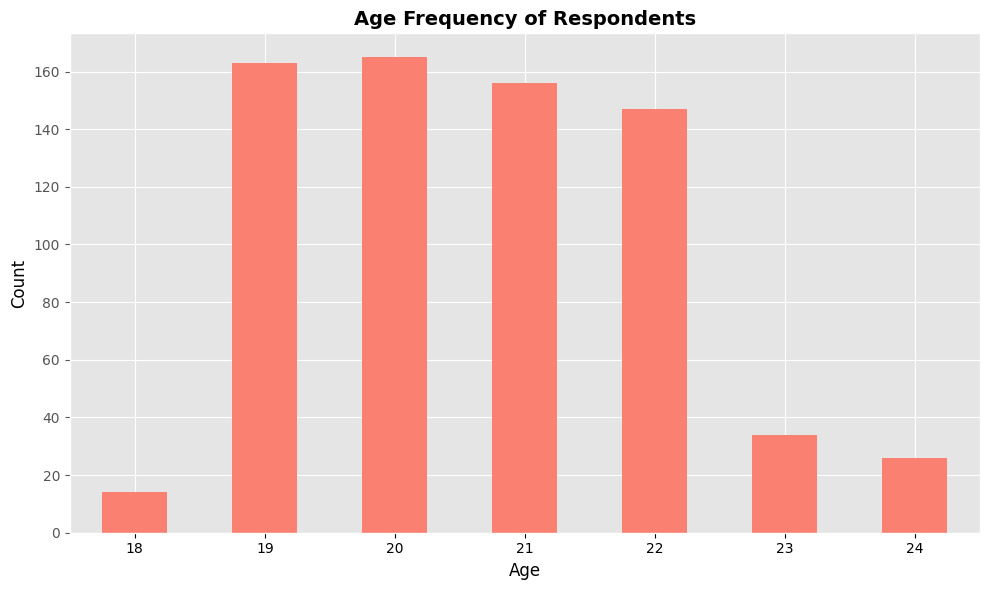

In [588]:
#Plotting age distribution of survey respondents

plt.figure(figsize=(10,6))
age_frequency=df['age'].value_counts().sort_values().sort_index(ascending=True)
age_frequency.plot(kind='bar', color='salmon')
plt.title('Age Frequency of Respondents', fontdict=title_style)
plt.xlabel('Age',fontdict={'color':'black'})
plt.ylabel('Count',fontdict={'color':'black'})
plt.tick_params(axis='x',rotation=0,colors='black')
plt.tight_layout()

plt.savefig('../outputs/univariate-analysis/age_distribution.png')

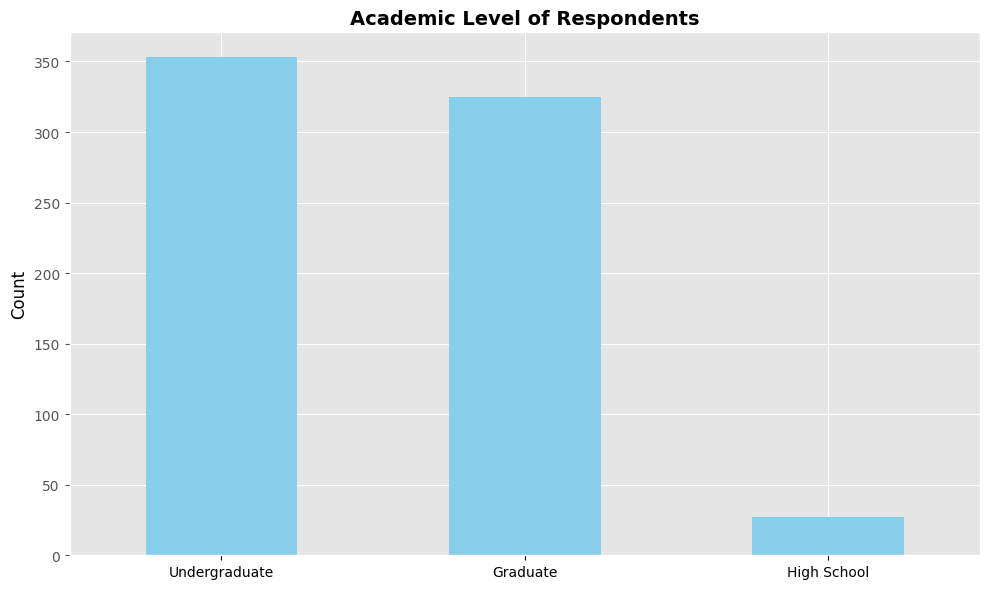

In [589]:
# Plotting the distribution of academic level 

plt.figure(figsize=(10,6))
academic_level_frequency=df['academic_level'].value_counts()
academic_level_frequency.plot(kind='bar', color='skyblue')
plt.title('Academic Level of Respondents', fontdict=title_style)
plt.xlabel('')
plt.ylabel('Count', fontdict={'color':'black'})
plt.tick_params(axis='x',rotation=0, colors='black')

plt.tight_layout()
plt.savefig('../outputs/univariate-analysis/academic-level-distribution.png')

## Key Observation
The majority of respondents are undergraduate and graduate students, with high school students being significantly underrepresented. This suggests the dataset skews toward college-age users, which should be kept in mind when generalizing findings — results may not be representative of younger or older age groups.

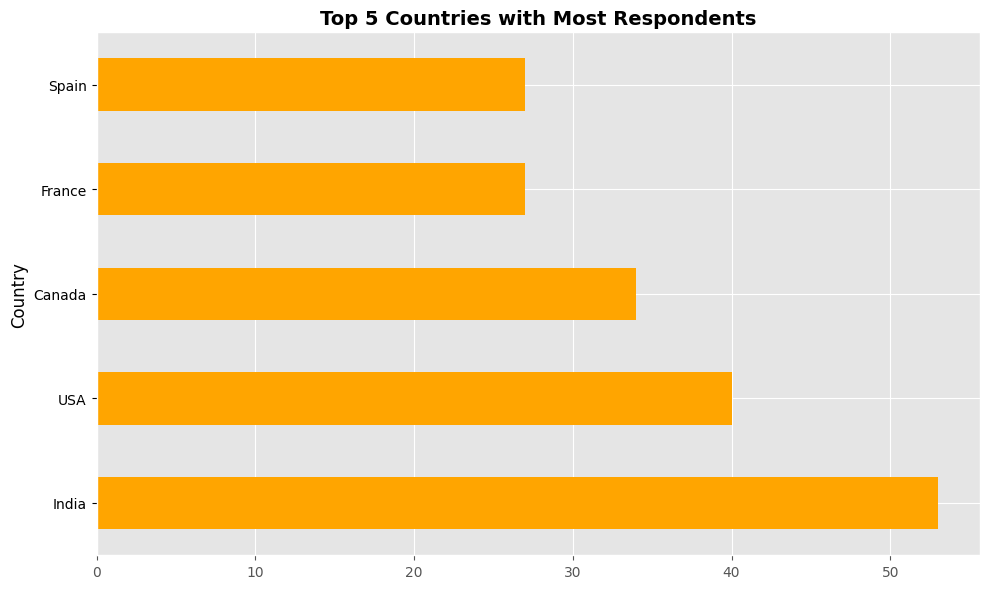

In [590]:
# Plotting the top 5 countries with most respondents

plt.figure(figsize=(10,6))

top_countries=df.country.value_counts().head()
top_countries.plot(kind='barh', color='orange')
plt.title('Top 5 Countries with Most Respondents', fontdict=title_style)
plt.ylabel('Country', color='black')
plt.tick_params(axis='y',colors='black')

plt.tight_layout()

plt.savefig('../outputs/univariate-analysis/most-frequent-countries.png')


In [591]:
underrepresented_countries=df.country.value_counts()[df.country.value_counts()==1].index.to_list()
underrepresented_countries

['Sweden',
 'Norway',
 'Belgium',
 'Austria',
 'Portugal',
 'Greece',
 'Thailand',
 'Vietnam',
 'Philippines',
 'Indonesia',
 'Taiwan',
 'Hong Kong',
 'Israel',
 'Egypt',
 'Morocco',
 'South Africa',
 'Nigeria',
 'Kenya',
 'Ghana',
 'Argentina',
 'Chile',
 'Colombia',
 'Peru',
 'Venezuela',
 'Ecuador',
 'Uruguay',
 'Paraguay',
 'Bolivia',
 'Costa Rica',
 'Panama',
 'Jamaica',
 'Trinidad',
 'Bahamas',
 'Iceland',
 'Romania',
 'Hungary',
 'Czech Republic',
 'Slovakia',
 'Croatia',
 'Serbia',
 'Slovenia',
 'Bulgaria',
 'Estonia',
 'Latvia',
 'Lithuania',
 'Ukraine',
 'Moldova',
 'Belarus',
 'Kazakhstan',
 'Uzbekistan',
 'Kyrgyzstan',
 'Tajikistan',
 'Armenia',
 'Georgia',
 'Azerbaijan',
 'Cyprus',
 'Malta',
 'Luxembourg',
 'Monaco',
 'Andorra',
 'San Marino',
 'Vatican City',
 'Liechtenstein',
 'Montenegro',
 'Albania',
 'North Macedonia',
 'Kosovo',
 'Bosnia',
 'Qatar',
 'Kuwait',
 'Bahrain',
 'Oman',
 'Jordan',
 'Lebanon',
 'Iraq',
 'Yemen',
 'Syria',
 'Afghanistan',
 'Bhutan']

## Key Observation
The dataset is dominated by respondents from **India, USA, Canada, France, and Spain**. Any generalizations drawn from this analysis will primarily reflect social media usage patterns in these countries. Results should be interpreted with caution when applying them to underrepresented regions.

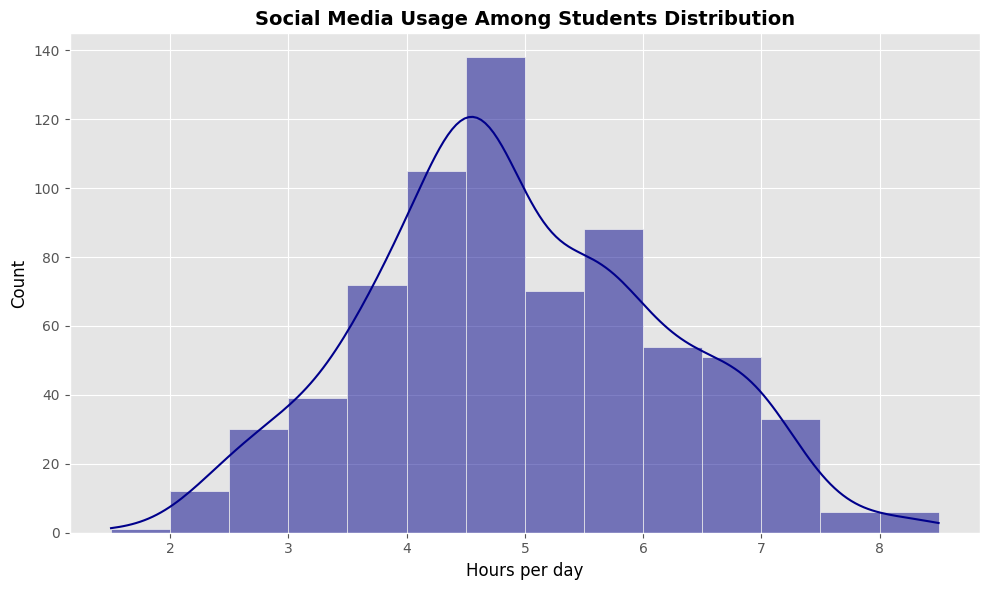

In [592]:
# Plotting daily social media usage distribution
plt.figure(figsize=(10,6))

sns.histplot(x='avg_daily_usage_hours', data=df, kde=True, color='darkblue', bins=14)
plt.title('Social Media Usage Among Students Distribution',fontdict=title_style)
plt.xlabel('Hours per day', fontdict={'color':'black'})
plt.ylabel('Count', fontdict={'color':'black'})

plt.tight_layout()

plt.savefig('../outputs/univariate-analysis/social-media-usage-distribution.png')


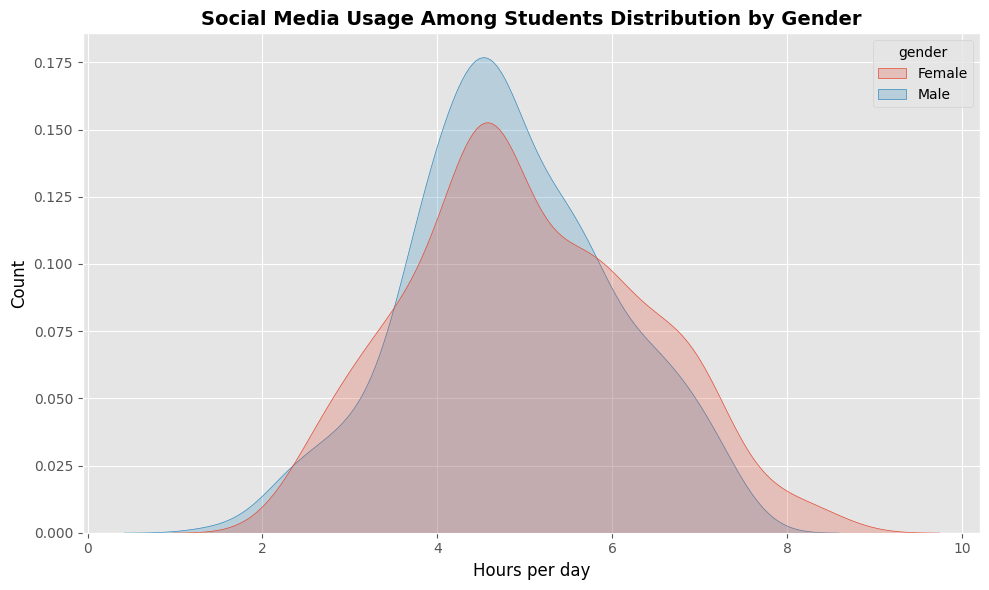

In [593]:
# Plotting daily social media usage distribution by gender
plt.figure(figsize=(10,6))

sns.kdeplot(x='avg_daily_usage_hours', data=df, fill=True, color=['blue','pink'],hue='gender')
plt.title('Social Media Usage Among Students Distribution by Gender',fontdict=title_style)
plt.xlabel('Hours per day', fontdict={'color':'black'})
plt.ylabel('Count', fontdict={'color':'black'})

plt.tight_layout()

plt.savefig('../outputs/univariate-analysis/social-media-usage-distribution-by-gender.png')


From this graph, we can observe slight but noticeable difference between social media usage habits between male and female respondents

## How many percent of their week time do students use social media?


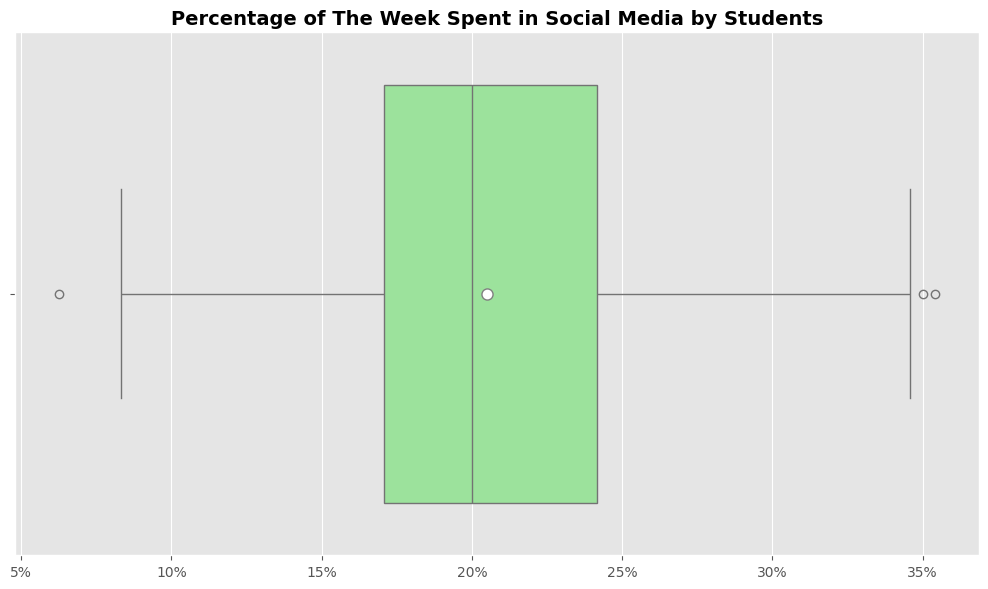

In [594]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,6))

weekly_usage_percentage=df.weekly_usage_ratio*100
sns.boxplot(x=weekly_usage_percentage, color='lightgreen', showmeans=True, meanprops={'marker':'o',
                                                                                      'markerfacecolor':'white',
                                                                                      'markeredgecolor':'grey',
                                                                                      'markersize':8})

plt.title('Percentage of The Week Spent in Social Media by Students', fontdict=title_style)
plt.xlabel('')

# Adding percentage signs to ticks
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()

plt.savefig('../outputs/univariate-analysis/weekly-social-media-usage-percentage-distribution.png')



## Key Observation
Half of all surveyed students dedicate roughly 17%–24% of their weekly time to social media. 
To better understand the consequences of such digital habits, we'll investigate the two outliers.

In [595]:
maximum_hours=df[df['avg_weekly_usage_hours']==df.avg_weekly_usage_hours.max()]
minimum_hours=df[df['avg_weekly_usage_hours']==df.avg_weekly_usage_hours.min()]

In [596]:
maximum_hours

,age,gender,academic_level,country,avg_daily_usage_hours,avg_weekly_usage_hours,weekly_usage_ratio,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,,,
497,19,Female,Undergraduate,USA,8.5,59.5,0.354167,Instagram,1,3.8,5,In Relationship,4,9


In [597]:
minimum_hours

,age,gender,academic_level,country,avg_daily_usage_hours,avg_weekly_usage_hours,weekly_usage_ratio,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,relationship_status,conflicts_over_social_media,addicted_score
student_id,,,,,,,,,,,,,,
7,23,Male,Graduate,Germany,1.5,10.5,0.0625,LinkedIn,0,8.0,9,Single,0,2


## Key Observation
The outliers suggest that heavy social media usage may have a notable impact on mental health and nightly sleep duration, 
as both variables show dramatic differences in the two extreme cases.

I have also noticed that a person with minimal social media usage indicated LinkedIn as their most used platform unlike a person with maximum hours who mostly uses Instagram. I would like to explore if there is a correlation between these two variables. Before that, I will inspect the list of all social media platforms present in the dataset

In [598]:
social_media_platforms=list(df.most_used_platform.unique())

# Bivariate and Multivariate Analysis
Now let's explore the relationships between variables in the dataset, focusing on two key questions:

1. Which aspects of student life are most influenced by social media usage, and in what way?
2. Does the platform a student uses most frequently relate to how much time they spend online?

To begin, I'll examine the relationship between `avg_daily_usage_hours` and `sleep_hours_per_night`. 
I assume that these two variables share an inverse linear relationship — as daily screen time increases, sleep duration decreases.

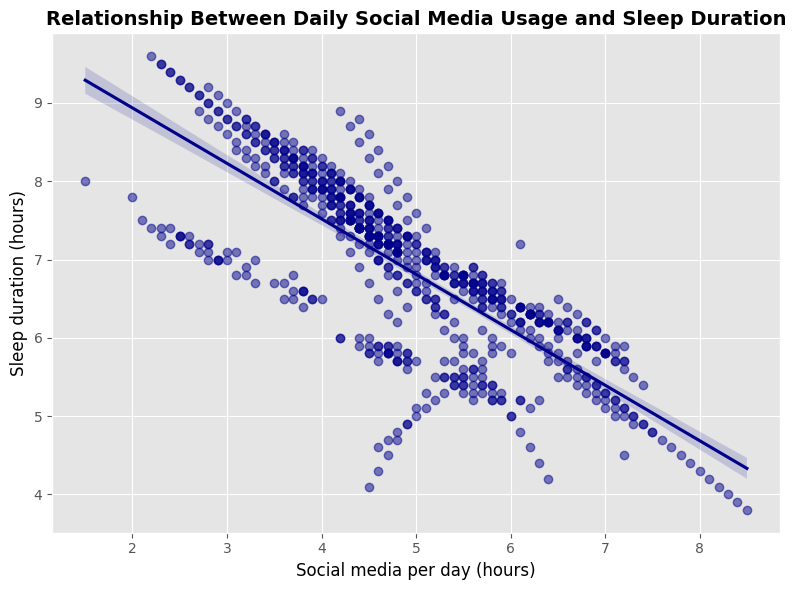

In [599]:
plt.figure(figsize=(8,6))
sns.regplot(x='avg_daily_usage_hours', y='sleep_hours_per_night', data=df, scatter_kws={'alpha':0.5}, color='darkblue')

plt.title('Relationship Between Daily Social Media Usage and Sleep Duration',fontdict=title_style)
plt.xlabel('Social media per day (hours)', fontdict={'color':'black'})
plt.ylabel('Sleep duration (hours)',fontdict={'color':'black'})

plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/social-media-and-sleep-duration.png')


# Key Observation
Despite some variation in the data, the overall trend supports a clear negative linear correlation between social media usage and sleep duration, confirming the initial hypothesis.
Now I want to look at the same relationship with data points separated by mental health score

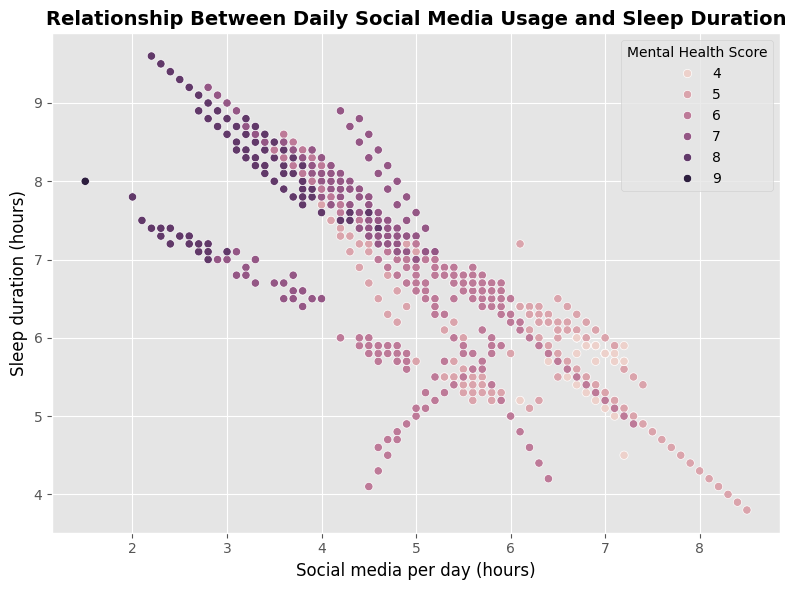

In [600]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='avg_daily_usage_hours', y='sleep_hours_per_night', data=df, hue='mental_health_score')

plt.title('Relationship Between Daily Social Media Usage and Sleep Duration',fontdict=title_style)
plt.xlabel('Social media per day (hours)', fontdict={'color':'black'})
plt.ylabel('Sleep duration (hours)',fontdict={'color':'black'})
plt.legend(title='Mental Health Score')

plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/media-and-sleep-versus-mental-health.png')


## Key Observation
The data clearly shows that sleep duration has a significant impact on mental health — students who sleep less tend to report poorer psychological wellbeing.

I would like to test the possibility that mental health is more influenced by relationship status than sleep duration. 
Perhaps single students report lower mental health scores, while those in a relationship report higher ones.

To do that, I will plot each `relationship_status` category against its mean `mental_health_score`.

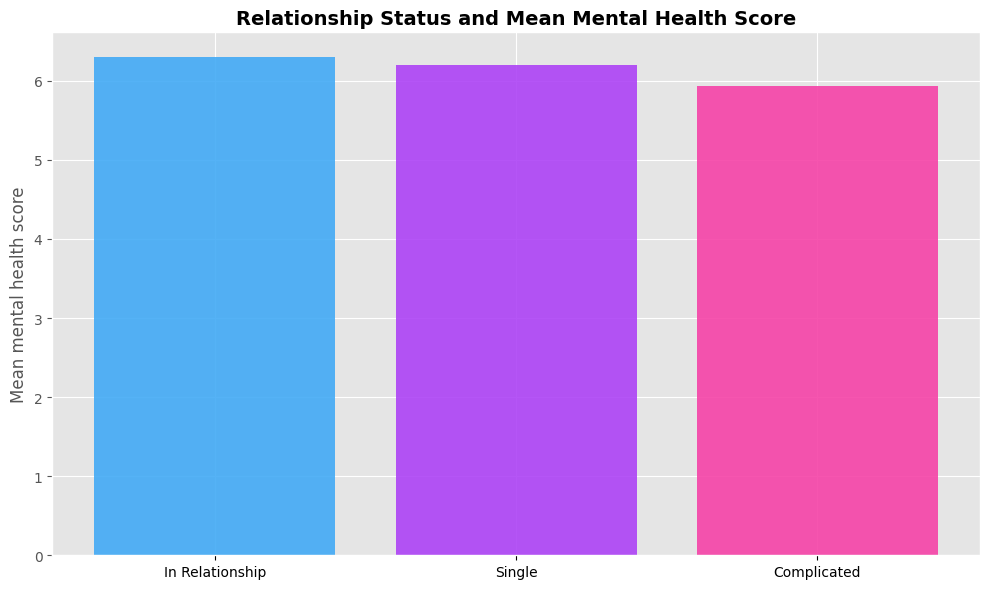

In [601]:
in_relationship_mh=df.query('relationship_status=="In Relationship"')['mental_health_score'].mean()
single_mh=df.query('relationship_status=="Single"')['mental_health_score'].mean()
complicated_mh=df.query('relationship_status=="Complicated"')['mental_health_score'].mean()

plt.figure(figsize=(10,6))
plt.bar(['In Relationship','Single','Complicated'],[in_relationship_mh,single_mh,complicated_mh], color=['#42aaf5','#ad42f5','#f542a7'], alpha=0.9)
plt.title('Relationship Status and Mean Mental Health Score',fontdict=title_style)
plt.ylabel('Mean mental health score')
plt.tick_params(axis='x',colors='black')

plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/relationship-status-and-mental-health.png')


In [602]:
df.mental_health_score.unique()

array([6, 8, 5, 7, 4, 9])

## Key Observation
While there is a slight correlation between relationship status and mental health score — with people in a relationship 
reporting the highest scores — the effect is not strong enough to suggest it influences `mental_health_score` more than 
`sleep_hours_per_night` does. The absence of outliers in `mental_health_score` also indicates no significant bias 
from `relationship_status` in this dataset.

## Most Used Platform vs. Daily Social Media Usage
Now, I would like to explore which social media platforms survey participants use and whether it affects the time they spend online

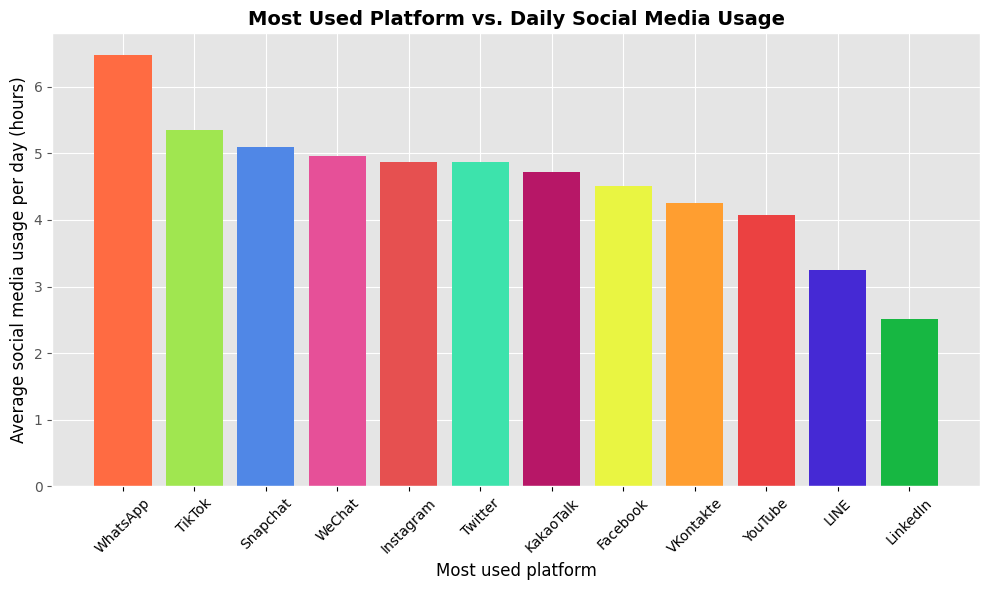

In [603]:
sorted_platforms=sorted(social_media_platforms,key=lambda x: df[df['most_used_platform']==x]['avg_daily_usage_hours'].mean(),reverse=True)


colors=['#ff6b42', '#a0e650','#5087e6','#e65098','#e65050','#3de3ac',
        "#b71767","#e9f542","#ff9e30","#eb4141","#4529d4","#17b742"]
fig, ax=plt.subplots(figsize=(10,6))

for s,color in zip(sorted_platforms,colors):
        ax.bar(s,df[df['most_used_platform']==s]['avg_daily_usage_hours'].mean(), color=color)

ax.tick_params(axis='x',rotation=45,colors='black')
ax.set_xlabel('Most used platform',fontdict={'color':'black'})
ax.set_ylabel('Average social media usage per day (hours)',fontdict={'color':'black'})
ax.set_title('Most Used Platform vs. Daily Social Media Usage',fontdict=title_style)

plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/platform-vs-daily-media-usage.png')


## Key Observation
There is no strong correlation between platform choice and daily usage time, with most platforms clustering 
between 4.5–5.5 hours. WhatsApp is an outlier at ~6.5 hours, while LinkedIn ranks lowest as expected given its professional nature.

Next, I'll examine how daily social media usage relates to `conflicts_over_social_media`, `addicted_score`, and `affects_academic_performance`.

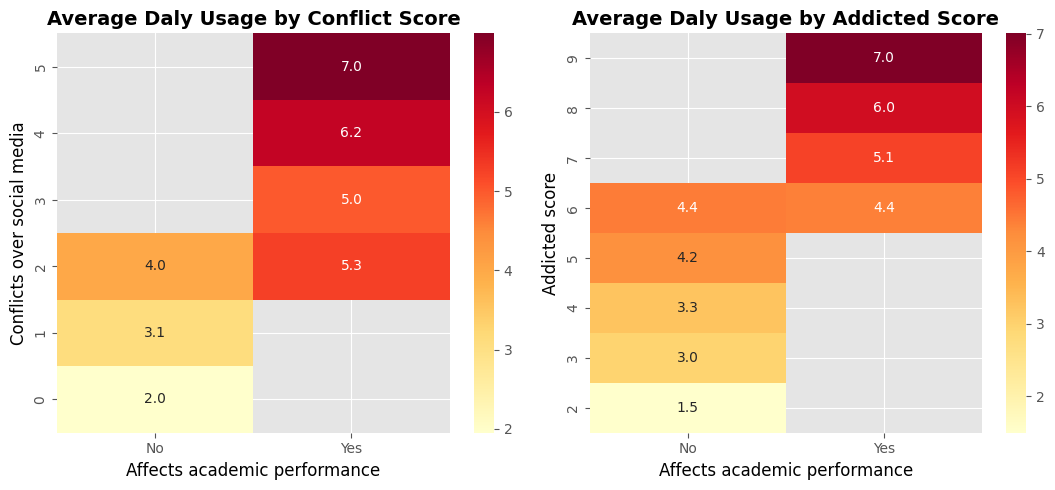

In [604]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col in zip(axes, ['conflicts_over_social_media', 'addicted_score']):
    pivot = df.groupby([col, 'affects_academic_performance'])['avg_daily_usage_hours'].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)

axes[0].set_title('Average Daly Usage by Conflict Score', fontdict=title_style)
axes[1].set_title('Average Daly Usage by Addicted Score',fontdict=title_style)

axes[0].set_xlabel('Affects academic performance',fontdict={'color':'black'})
axes[1].set_xlabel('Affects academic performance',fontdict={'color':'black'})

axes[0].set_ylabel('Conflicts over social media',fontdict={'color':'black'})
axes[1].set_ylabel('Addicted score',fontdict={'color':'black'})

axes[0].set_xticklabels(['No','Yes'])
axes[1].set_xticklabels(['No','Yes'])

axes[0].invert_yaxis()
axes[1].invert_yaxis()

plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/daily-usage-effects-heatmap.png')

## Key Observation
The heatmaps show that students averaging more than ~4.5–5 hours of daily social media use are more likely to report academic impact, higher addiction scores, and more frequent conflicts with others. Conversely, lower usage is associated with fewer conflicts and a lower perceived addiction level. This suggests that daily usage time has a strong influence on both interpersonal conflict and self-reported addiction.

To wrap up the bivariate analysis, I'll examine the correlation matrix across all numeric variables in the dataset. 
This will help consolidate the findings so far and lay the groundwork for potential predictive modeling.

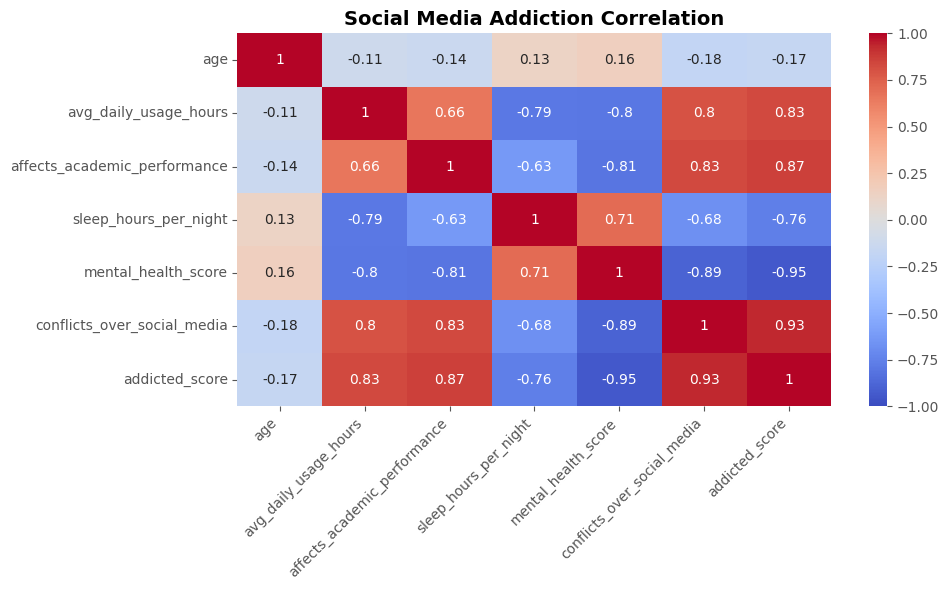

In [605]:
correlation=df.corr(numeric_only=True).drop(columns=['avg_weekly_usage_hours','weekly_usage_ratio'],index=['avg_weekly_usage_hours','weekly_usage_ratio'])

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.tick_params(axis='x',rotation=45)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), ha='right')


plt.title('Social Media Addiction Correlation', fontdict=title_style)
plt.tight_layout()

plt.savefig('../outputs/multivariate-analysis/social-media-addiction-correlation.png')

Note that `affects_academic_performance` is a binary variable (0/1), so the heatmap may not accurately represent its correlation values

## Key Observation
The correlation heatmap confirms that `avg_daily_usage_hours` has the strongest relationships with the following variables:

- `sleep_hours_per_night` — strong negative correlation (-0.79), more usage means less sleep
- `mental_health_score` — strong negative correlation (-0.8), more usage means poorer mental health
- `conflicts_over_social_media` — strong positive correlation (0.8), more usage means more conflicts
- `addicted_score` — strong positive correlation (0.83), more usage means higher addiction

# Conclusion

To conclude the bivariate analysis, let's revisit the two questions posed at the start.

The analysis reveals that social media usage has a significant impact on students' social and academic lives. 
Higher daily usage is associated with disrupted sleep patterns, which in turn negatively affects mental health. 
Students who spend more time online are also more likely to report that it interferes with their academic performance, 
and tend to experience more interpersonal conflicts. Unsurprisingly, greater usage also correlates with higher self-reported addiction scores.

On the other hand, no meaningful correlation was found between platform choice and daily usage time. 
While small differences in mean usage exist across platforms, they are not substantial enough to suggest that 
the platform itself drives how much time a student spends online.